# Spatial variation in road casualty risk across London MSOAs: descriptive, spatial, and predictive analysis

## Preparation

- Number of words: 1587

- Runtime: under 1 hour (*4-core ARM64 container environment with approximately 1.9 GiB RAM*)

- Coding environment: Jupyter Notebook

- Reproducibility note: This notebook is designed to run from the project folder using relative file paths. All required input files should be placed in a folder named `DSSS_data` in the same directory as the notebook, while outputs are written to an `outputs` folder created automatically at runtime. This structure avoids dependence on a specific local machine path and improves portability across environments.

## Table of contents

1. [Introduction](#Introduction)

2. [Research questions](#Research-questions)

3. [Data](#Data)  

4. [Methodology](#Methodology)

5. [Data Preprocessing and Analysis](#data-preprocessing-and-analysis)

6. [Results and discussion](#Results-and-discussion)

7. [Conclusion](#Conclusion)

8. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Road traffic injury remains a significant public health and urban policy issue. Prior research points to three relevant findings. First, road traffic harm continues to impose a major global burden, with around 1.19 million deaths annually, and this burden is socially unequal because lower socioeconomic groups face higher crash risk even in high-income countries (World Health Organisation, 2023). Second, evidence from England suggests that road injury is socially and geographically uneven, with deprivation associated with unequal safety outcomes across places (Graham, Glaister and Anderson, 2005; Steinbach, Edwards and Grundy, 2013). Third, wider reviews indicate that traffic safety is shaped not only by immediate road conditions but also by the built environment, including broader urban structure and spatial form (Ewing and Dumbaugh, 2009).

This study therefore examines London at the Middle Layer Super Output Area (MSOA) level to assess whether casualty risk is spatially clustered and which local characteristics are most strongly associated with higher rates. This focus is further supported by earlier London evidence showing that crash outcomes display spatial correlation and heterogeneity, indicating that neighbouring areas may share similar risk profiles rather than operating independently (Quddus, 2008).

Road casualties are not evenly distributed across cities, and understanding where risk is concentrated is important for targeted intervention. Existing research suggests that casualty patterns are shaped not only by immediate road conditions but also by broader urban structure, density, and socio-economic inequality.

## Research questions

[[ go back to the top ]](#Table-of-contents)

This study investigates spatial inequality in road casualty risk across London neighbourhoods. It addresses three related questions:

1. How unevenly are annual road casualty rates distributed across London MSOAs?
   
2. Do high-rate and low-rate MSOAs exhibit significant spatial clustering?

3. To what extent can variation in annual road casualty rates across London MSOAs be accounted for by collision conditions, spatial intensity, and neighbourhood deprivation?

## Data

[[ go back to the top ]](#Table-of-contents)

The primary source of casualty data for this study comes from the UK Department for Transport (DfT). This dataset provides detailed records of road casualties across London, with annual
statistics available for analysis at the MSOA level. The dataset
covers the period from 2020 to 2024, allowing for the analysis of casualty data over a five-year span.
To ensure comparability between areas of different sizes, we standardised the casualty counts to a
rate per 1,000 residents in each MSOA, using the 2024 population data for this calculation.

#### Table A. Variables Used in the Analysis

| **Variable Name**                        | **Type**                  | **Description**                                                                                                                                  | **Source/Reference**                                   |
|------------------------------------------|---------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------|
| **Annual Casualty Rate per 1,000 Residents** | Dependent Variable         | Standardised casualty rate for each MSOA, calculated by dividing total casualties by population and multiplying by 1,000.                          | DfT                   |
| **IMD Score (Index of Multiple Deprivation)**  | Explanatory Variable       | Socio-economic deprivation index for each MSOA, used to measure spatial inequalities in road safety outcomes.                                      | Office for National Statistics (ONS)                   |
| **Collision Conditions**                  | Explanatory Variable       | Includes factors such as **wet road conditions**, **dark road conditions**, and **high-speed zones**. These are factors likely affecting crash severity. | DfT                      |
| **Population Density**                    | Explanatory Variable       | Population density (residents per square kilometre) for each MSOA. Used to measure urban intensity.                                              | ONS Census 2021                                       |
| **Traffic Density**                       | Explanatory Variable       | Traffic flow data, indicating the volume of vehicles per unit of area. It influences collision risk, particularly in high-density areas.            | DfT                      |
| **Road Type**                             | Control Variable           | Classification of roads (e.g., residential, arterial, motorway). Determines differences in casualty rates based on road usage type.                 | DfT                      |
| **Speed Limit**                           | Control Variable           | Speed limits for different roads. Higher speeds generally lead to more severe crashes.                                                            | DfT                      |

#### Data Preparation
Records with missing or invalid coordinates were removed before spatial processing. Collision records were then joined to MSOA boundaries and aggregated to the area level. After merging with population data, MSOAs with no joined collisions were assigned zeros for total collisions and total casualties. Annual casualty rates per 1,000 residents were then calculated to allow comparison across MSOAs of different sizes. Key variables were grouped into discrete categories, including high versus low speed conditions and relative deprivation levels.

#### Limitations

Some smaller or less densely populated MSOAs had missing data, which may affect generalisability despite the imputation strategy. Because the dataset is based on reported accidents, minor incidents may be underrecorded, which could lead to underestimation of casualty rates. There is also a small temporal mismatch, as casualty data cover 2020 to 2024 while the population estimates are from mid-2024. Finally, as the analysis focuses only on London MSOAs, the findings may not be directly transferable to other urban contexts.

## Methodology

[[ go back to the top ]](#Table-of-contents)

The two-way partial dependence plot shows how predicted casualty rates vary jointly across the two most important predictors, helping to identify possible interaction effects within the Random Forest model.

OLS is used as an interpretable baseline to assess associations between casualty rates and area-level predictors, while tree-based models test whether more flexible non-linear relationships improve predictive performance. Because the analysis is observational and area-based, the results indicate association rather than causation.

The analysis has four stages. First, descriptive statistics, histograms, and choropleth maps assess whether casualty rates are uneven across London. Second, Global Moran’s I, the Moran scatterplot, and LISA test for spatial clustering, with LISA identifying local clusters and outliers (Anselin, 1995). Third, nested OLS models are estimated: Model A includes collision conditions, Model B adds collision and population density, and Model C adds deprivation. Finally, a Decision Tree and Random Forest are estimated as non-linear predictive models. Random Forest is well suited to capturing interactions and non-linear relationships, and has been shown to perform well in road-safety research (Breiman, 2001; Obasi and Benson, 2023).

#### Table B. Methodology flow chart

![Methodology flow chart](Methodology.jpg)

## Data Preprocessing and Analysis

[[ go back to the top ]](#table-of-contents)

In [1]:
from pathlib import Path
import os
import warnings

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Project paths relative to the notebook location
project_root = Path(".").resolve()
data_dir = project_root / "DSSS_data"
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

# Input files
collision_file = data_dir / "dft-road-casualty-statistics-collision-last-5-years.csv"
casualty_file = data_dir / "dft-road-casualty-statistics-casualty-last-5-years.csv"
vehicle_file = data_dir / "dft-road-casualty-statistics-vehicle-last-5-years.csv"
msoa_file = data_dir / "MSOA_2021_EW_BGC_V3.shp"
population_file = data_dir / "sapemsoasyoa20222024.xlsx"
imd_file = data_dir / "IMD_2025.csv"
lookup_file = data_dir / "lookup.csv"

# Data cleaning function
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.strip("_")
    )
    return df

# Check required files before running
required_files = [
    collision_file,
    casualty_file,
    vehicle_file,
    msoa_file,
    population_file,
    imd_file,
    lookup_file
]

missing_files = [str(f) for f in required_files if not f.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n" + "\n".join(missing_files) +
        "\n\nPlease place all input files inside the 'DSSS_data' folder next to this notebook."
    )

In [2]:
collision_usecols = [
    "collision_index",
    "longitude",
    "latitude",
    "number_of_casualties",
    "speed_limit",
    "road_type",
    "junction_detail",
    "light_conditions",
    "road_surface_conditions",
    "urban_or_rural_area"
]

collisions_raw = pd.read_csv(
    collision_file,
    usecols=collision_usecols,
    low_memory=True
)

collisions_raw = clean_columns(collisions_raw)

In [3]:
# MSOA boundaries
if "SHAPE_RESTORE_SHX" in os.environ:
    del os.environ["SHAPE_RESTORE_SHX"]
    
msoa_raw = gpd.read_file(str(msoa_file))
msoa_raw = clean_columns(msoa_raw)
msoa = msoa_raw[["msoa21cd", "msoa21nm", "geometry"]].copy()

In [4]:
# Collisions
collision_cols_min = [
    "collision_index",
    "longitude",
    "latitude",
    "number_of_casualties",
    "speed_limit",
    "road_type",
    "junction_detail",
    "light_conditions",
    "road_surface_conditions",
    "urban_or_rural_area"
]

collisions = collisions_raw[collision_cols_min].copy()

# Clean Collision Fields 
for col in ["longitude", "latitude", "number_of_casualties", "speed_limit"]:
    collisions[col] = pd.to_numeric(collisions[col], errors="coerce")

collisions = collisions[
    collisions["longitude"].notna() &
    collisions["latitude"].notna() &
    (collisions["longitude"] != 0) &
    (collisions["latitude"] != 0)
].copy()

In [5]:
# Convert to GeoDataFrame
collisions_gdf = gpd.GeoDataFrame(
    collisions,
    geometry=gpd.points_from_xy(collisions["longitude"], collisions["latitude"]),
    crs="EPSG:4326"
)

collisions_gdf = collisions_gdf.to_crs(msoa.crs)

In [6]:
# Spatial Join to MSOAs
collisions_msoa = gpd.sjoin(
    collisions_gdf,
    msoa,
    how="inner",
    predicate="within"
)

In [7]:
collisions_msoa = collisions_msoa[
    [
        "collision_index",
        "number_of_casualties",
        "speed_limit",
        "road_type",
        "junction_detail",
        "light_conditions",
        "road_surface_conditions",
        "urban_or_rural_area",
        "msoa21cd",
        "msoa21nm",
        "geometry"
    ]
].copy()

In [8]:
# Aggregate collision data to MSOA level
collision_counts_msoa = (
    collisions_msoa
    .groupby(["msoa21cd", "msoa21nm"], as_index=False)
    .agg(
        total_collisions=("collision_index", "size"),
        total_casualties=("number_of_casualties", "sum"),
        avg_speed_limit=("speed_limit", "mean"),
        prop_dark=("light_conditions", lambda s: (pd.to_numeric(s, errors="coerce") != 1).mean()),
        prop_wet=("road_surface_conditions", lambda s: pd.to_numeric(s, errors="coerce").isin([2, 3, 4]).mean()),
        prop_junction=("junction_detail", lambda s: (pd.to_numeric(s, errors="coerce") != 0).mean()),
        prop_urban=("urban_or_rural_area", lambda s: (pd.to_numeric(s, errors="coerce") == 1).mean())
    )
)

print(collision_counts_msoa.shape)
collision_counts_msoa.head()

(7263, 9)


,msoa21cd,msoa21nm,total_collisions,total_casualties,avg_speed_limit,prop_dark,prop_wet,prop_junction,prop_urban
0,E02000001,City of London 001,773,832,20.232859,0.337646,0.174644,0.673997,0.989651
1,E02000002,Barking and Dagenham 001,68,90,33.823529,0.397059,0.176471,0.632353,0.882353
2,E02000003,Barking and Dagenham 002,215,278,31.488372,0.339535,0.241860,0.790698,0.944186
3,E02000004,Barking and Dagenham 003,24,30,30.000000,0.333333,0.125000,0.166667,1.000000
4,E02000005,Barking and Dagenham 004,73,99,29.178082,0.301370,0.191781,0.739726,1.000000


In [9]:
# Read population
xls = pd.ExcelFile(population_file)

# MSOA 2021
sheet_2024 = "Mid-2024 MSOA 2021"

pop_2024 = pd.read_excel(population_file, sheet_name=sheet_2024, header=3)
pop_2024 = clean_columns(pop_2024)

In [10]:
# Population table
population_2024 = pop_2024.rename(columns={
    "lad_2023_code": "lad23cd",
    "lad_2023_name": "lad23nm",
    "msoa_2021_code": "msoa21cd",
    "total": "population"
})[["lad23cd", "lad23nm", "msoa21cd", "population"]].copy()

population_2024["msoa21cd"] = population_2024["msoa21cd"].astype(str).str.strip()
population_2024["lad23nm"] = population_2024["lad23nm"].astype(str).str.strip()
population_2024["population"] = pd.to_numeric(population_2024["population"], errors="coerce")


In [11]:
msoa["msoa21cd"] = msoa["msoa21cd"].astype(str).str.strip()
collision_counts_msoa["msoa21cd"] = collision_counts_msoa["msoa21cd"].astype(str).str.strip()
population_2024["msoa21cd"] = population_2024["msoa21cd"].astype(str).str.strip()

# Merge MSOA boundaries, collision summaries, and population
msoa_analysis = (
    msoa
    .merge(collision_counts_msoa, on=["msoa21cd", "msoa21nm"], how="left")
    .merge(population_2024[["msoa21cd", "lad23cd", "lad23nm", "population"]], on="msoa21cd", how="left")
)

# Fill missing collision fields with zero where an MSOA has no joined collisions
fill_zero_cols = [
    "total_collisions",
    "total_casualties",
    "avg_speed_limit",
    "prop_dark",
    "prop_wet",
    "prop_junction",
    "prop_urban"
]

for col in ["total_collisions", "total_casualties"]:
    msoa_analysis[col] = msoa_analysis[col].fillna(0)

In [12]:
# Casualty rate variable
msoa_analysis["annual_avg_casualty_rate_per_1000"] = (
    msoa_analysis["total_casualties"] / 5 / msoa_analysis["population"] * 1000
)

msoa_analysis["five_year_casualty_rate_per_1000"] = (
    msoa_analysis["total_casualties"] / msoa_analysis["population"] * 1000
)

msoa_analysis[[
    "msoa21cd",
    "msoa21nm",
    "total_casualties",
    "population",
    "annual_avg_casualty_rate_per_1000"
]].head()

msoa_analysis[[
    "total_collisions",
    "total_casualties",
    "population",
    "annual_avg_casualty_rate_per_1000"
]].describe()

,total_collisions,total_casualties,population,annual_avg_casualty_rate_per_1000
count,7264.000000,7264.000000,7264.000000,7264.000000
mean,66.447412,84.330259,8508.629130,1.969449
std,49.988207,62.679067,2014.411604,1.397317
min,0.000000,0.000000,2366.000000,0.000000
25%,34.000000,42.000000,7011.000000,1.072058
50%,53.000000,68.000000,8182.000000,1.625405
75%,84.000000,108.000000,9645.000000,2.483287
max,922.000000,1033.000000,19993.000000,29.400882


In [13]:
# Highest MSOA
msoa_analysis[[
    "msoa21cd",
    "msoa21nm",
    "lad23nm",
    "total_casualties",
    "population",
    "annual_avg_casualty_rate_per_1000"
]].sort_values("annual_avg_casualty_rate_per_1000", ascending=False).head(10)

,msoa21cd,msoa21nm,lad23nm,total_casualties,population,annual_avg_casualty_rate_per_1000
925,E02000977,Westminster 018,Westminster,1033.0,7027,29.400882
920,E02000972,Westminster 013,Westminster,736.0,8358,17.611869
4736,E02004929,St Albans 006,St Albans,482.0,6193,15.565962
926,E02000978,Westminster 019,Westminster,552.0,7538,14.645795
4707,E02004899,Hertsmere 004,Hertsmere,373.0,5323,14.014653
6850,E02007111,Hackney 033,Hackney,453.0,6977,12.985524
918,E02000970,Westminster 011,Westminster,441.0,7053,12.505317
183,E02000193,Camden 028,Camden,420.0,7167,11.720385
6099,E02006344,Guildford 001,Guildford,513.0,9091,11.285887
6293,E02006542,Arun 001,Arun,314.0,5673,11.069981


In [14]:
# Save
msoa_analysis.to_file(output_dir / "msoa_analysis.gpkg", driver="GPKG")

msoa_analysis.drop(columns="geometry").to_csv(
    output_dir / "msoa_analysis.csv",
    index=False
)

In [15]:
# Filter to London MSOA
london_lads = [
    "Barking and Dagenham",
    "Barnet",
    "Bexley",
    "Brent",
    "Bromley",
    "Camden",
    "Croydon",
    "Ealing",
    "Enfield",
    "Greenwich",
    "Hackney",
    "Hammersmith and Fulham",
    "Haringey",
    "Harrow",
    "Havering",
    "Hillingdon",
    "Hounslow",
    "Islington",
    "Kensington and Chelsea",
    "Kingston upon Thames",
    "Lambeth",
    "Lewisham",
    "Merton",
    "Newham",
    "Redbridge",
    "Richmond upon Thames",
    "Southwark",
    "Sutton",
    "Tower Hamlets",
    "Waltham Forest",
    "Wandsworth",
    "Westminster",
    "City of London"
]

msoa_analysis_london = msoa_analysis[
    msoa_analysis["lad23nm"].isin(london_lads)
].copy()

print("Missing population:", msoa_analysis_london["population"].isna().sum())
print("Duplicate MSOA codes:", msoa_analysis_london["msoa21cd"].duplicated().sum())

Missing population: 0
Duplicate MSOA codes: 0


#### Data Analysis
[[Go back to the top]](#Table-of-contents)

This analysis begins by examining how annual road casualty rates vary across London MSOAs. This first stage aims to establish whether casualty risk is spatially uneven and whether high-rate areas are associated with particular urban conditions.

In [16]:
# Table 1. Substantial variation in total collisions, total casualties, population, and annual casualty rates across London MSOAs
msoa_analysis_london[[
    "msoa21cd",
    "msoa21nm",
    "lad23nm",
    "total_casualties",
    "population",
    "annual_avg_casualty_rate_per_1000"
]].head()

,msoa21cd,msoa21nm,lad23nm,total_casualties,population,annual_avg_casualty_rate_per_1000
0,E02000001,City of London 001,City of London,832.0,15111,11.011846
1,E02000002,Barking and Dagenham 001,Barking and Dagenham,90.0,8820,2.040816
2,E02000003,Barking and Dagenham 002,Barking and Dagenham,278.0,12655,4.393520
3,E02000004,Barking and Dagenham 003,Barking and Dagenham,30.0,7056,0.850340
4,E02000005,Barking and Dagenham 004,Barking and Dagenham,99.0,11630,1.702494


This suggests that road safety risk is unevenly distributed rather than uniform across the city. Because the dependent variable is expressed as a rate per 1,000 residents, the analysis focuses on relative local risk rather than raw casualty counts, which is more appropriate for comparing areas with different population sizes.

In [17]:
# Descriptive summary for London
print(msoa_analysis_london.shape)

print(
    msoa_analysis_london[[
        "total_collisions",
        "total_casualties",
        "population",
        "annual_avg_casualty_rate_per_1000"
    ]].describe()
)

(1002, 15)
       total_collisions  total_casualties    population  \
count       1002.000000       1002.000000   1002.000000   
mean         111.154691        128.089820   9071.592814   
std           73.930436         83.724322   1958.130270   
min            7.000000          8.000000   5274.000000   
25%           65.000000         74.000000   7684.000000   
50%           96.000000        110.000000   8747.000000   
75%          138.750000        160.000000  10122.750000   
max          922.000000       1033.000000  16767.000000   

       annual_avg_casualty_rate_per_1000  
count                        1002.000000  
mean                            2.837638  
std                             1.886663  
min                             0.290223  
25%                             1.734322  
50%                             2.466529  
75%                             3.405395  
max                            29.400882  


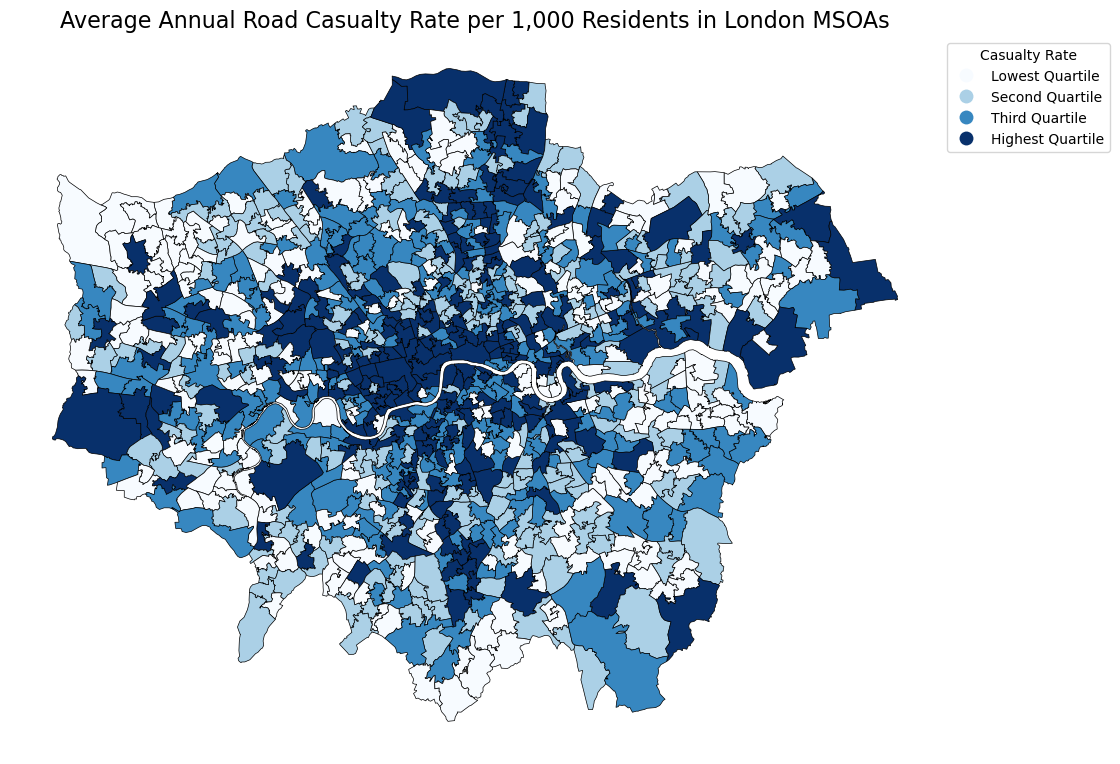

In [18]:
# Figure 1. Average annual road casualty rate per 1,000 residents, London MSOAs
import matplotlib.pyplot as plt
import pandas as pd

msoa_analysis_london["casualty_quartiles"] = pd.qcut(
    msoa_analysis_london["annual_avg_casualty_rate_per_1000"], 4, labels=["Lowest Quartile", "Second Quartile", "Third Quartile", "Highest Quartile"]
)

fig, ax = plt.subplots(figsize=(12, 12))

msoa_analysis_london.plot(
    column="casualty_quartiles",
    cmap="Blues",  
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "bbox_to_anchor": (1, 1),
        "title": "Casualty Rate",
        "loc": "upper left"
    }
)

ax.set_title("Average Annual Road Casualty Rate per 1,000 Residents in London MSOAs", fontsize=16)
ax.axis("off")

plt.show()

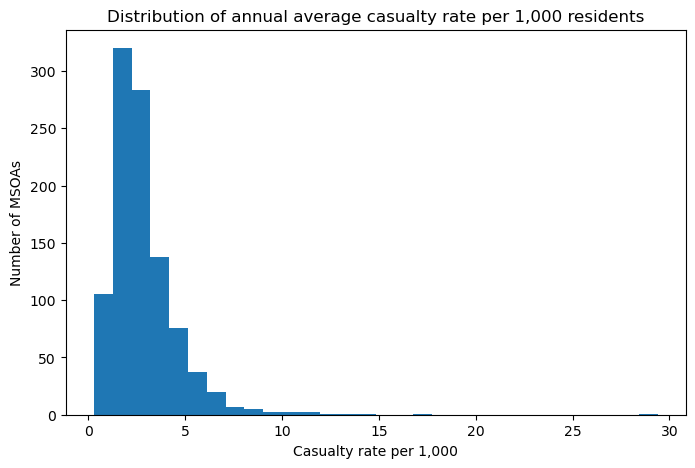

In [19]:
# Figure 2: Distribution of annual average casualty rate per 1,000 residents
fig, ax = plt.subplots(figsize=(8, 5))

msoa_analysis_london["annual_avg_casualty_rate_per_1000"].plot.hist(
    bins=30,
    ax=ax
)

ax.set_title("Distribution of annual average casualty rate per 1,000 residents")
ax.set_xlabel("Casualty rate per 1,000")
ax.set_ylabel("Number of MSOAs")

plt.show()

The distribution of annual casualty rates is positively skewed, with most MSOAs clustered at lower rates and a smaller number of areas exhibiting much higher values. This indicates the presence of high-risk outliers, which is analytically important because it suggests that a small number of urban areas account for disproportionately elevated casualty risk. 

#### Spatial descriptive analysis and autocorrelation
After describing the distribution of casualty rates, the next step is to examine whether these values are spatially clustered. This stage adds contextual density measures and formally tests spatial autocorrelation using Moran’s I and Local Indicators of Spatial Association.

In [20]:
# projected CRS - British National Grid
analysis_gdf = msoa_analysis_london.copy()

if analysis_gdf.crs is None:
    raise ValueError("GeoDataFrame has no CRS. Check your boundary file before continuing.")

if analysis_gdf.crs.to_epsg() != 27700:
    analysis_gdf = analysis_gdf.to_crs(27700)

print("Working CRS:", analysis_gdf.crs)

Working CRS: EPSG:27700


In [21]:
# Area and density variable 
analysis_gdf["area_km2"] = analysis_gdf.geometry.area / 1_000_000

analysis_gdf["collision_density_per_km2"] = (
    analysis_gdf["total_collisions"] / analysis_gdf["area_km2"]
)

analysis_gdf["pop_density_per_km2"] = (
    analysis_gdf["population"] / analysis_gdf["area_km2"]
)

analysis_gdf[[
    "msoa21cd",
    "msoa21nm",
    "area_km2",
    "total_collisions",
    "collision_density_per_km2",
    "population",
    "pop_density_per_km2"
]].head()

,msoa21cd,msoa21nm,area_km2,total_collisions,collision_density_per_km2,population,pop_density_per_km2
0,E02000001,City of London 001,2.892550,773.0,267.238271,15111,5224.110615
1,E02000002,Barking and Dagenham 001,2.166168,68.0,31.391833,8820,4071.705443
2,E02000003,Barking and Dagenham 002,2.143848,215.0,100.286968,12655,5902.937609
3,E02000004,Barking and Dagenham 003,2.491467,24.0,9.632880,7056,2832.066710
4,E02000005,Barking and Dagenham 004,1.186372,73.0,61.532133,11630,9802.996041


Collision density captures the spatial concentration of incidents, while population density measures residential concentration. Their effects may differ because dense areas can combine higher exposure with lower speeds and better pedestrian infrastructure.

Two additional contextual measures were constructed for later analysis: collision density per square kilometre and population density per square kilometre. 

In [22]:
# Distributions for the new variable
analysis_gdf[[
    "area_km2",
    "collision_density_per_km2",
    "pop_density_per_km2",
    "annual_avg_casualty_rate_per_1000"
]].describe()

,area_km2,collision_density_per_km2,pop_density_per_km2,annual_avg_casualty_rate_per_1000
count,1002.000000,1002.000000,1002.000000,1002.000000
mean,1.570196,116.442157,9156.619433,2.837638
std,1.847528,100.158407,5138.126241,1.886663
min,0.293924,3.652883,302.565665,0.290223
25%,0.702590,42.650326,5141.244812,1.734322
50%,1.117809,82.812712,8334.955036,2.466529
75%,1.724984,160.300509,12574.138438,3.405395
max,22.448020,650.404674,27451.148601,29.400882


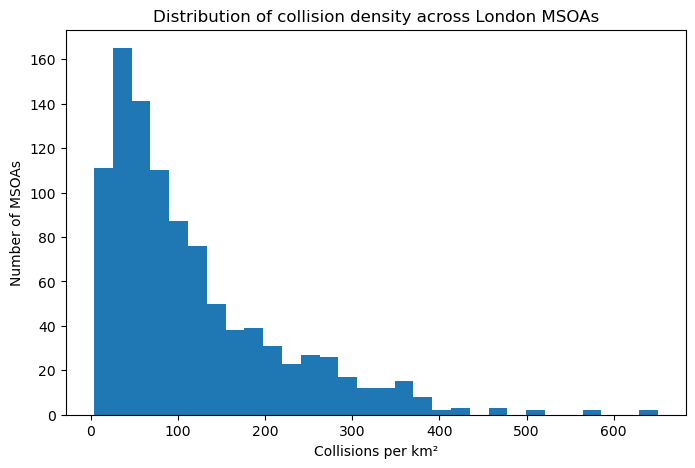

In [23]:
# Figure 3. Distribution of collision density across London MSOAs
fig, ax = plt.subplots(figsize=(8, 5))

analysis_gdf["collision_density_per_km2"].plot.hist(
    bins=30,
    ax=ax
)

ax.set_title("Distribution of collision density across London MSOAs")
ax.set_xlabel("Collisions per km²")
ax.set_ylabel("Number of MSOAs")

plt.show()

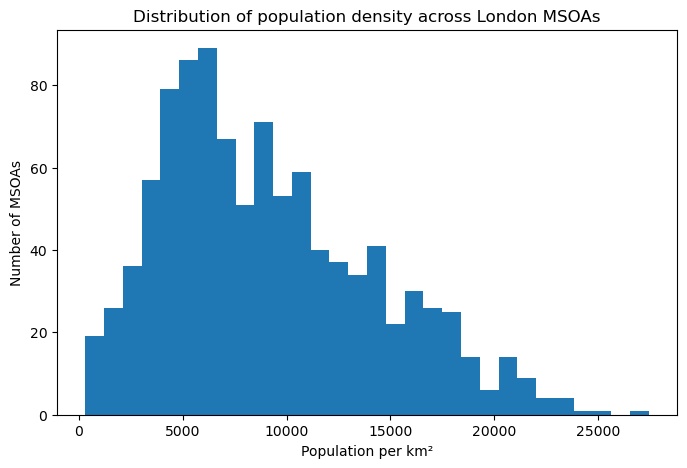

In [24]:
# Figure 4. Distribution of population density across London MSOAs
fig, ax = plt.subplots(figsize=(8, 5))

analysis_gdf["pop_density_per_km2"].plot.hist(
    bins=30,
    ax=ax
)

ax.set_title("Distribution of population density across London MSOAs")
ax.set_xlabel("Population per km²")
ax.set_ylabel("Number of MSOAs")

plt.show()

The distributions of collision density and population density are also uneven across London MSOAs. This suggests that casualty risk may partly reflect broader urban concentration rather than only local collision conditions.

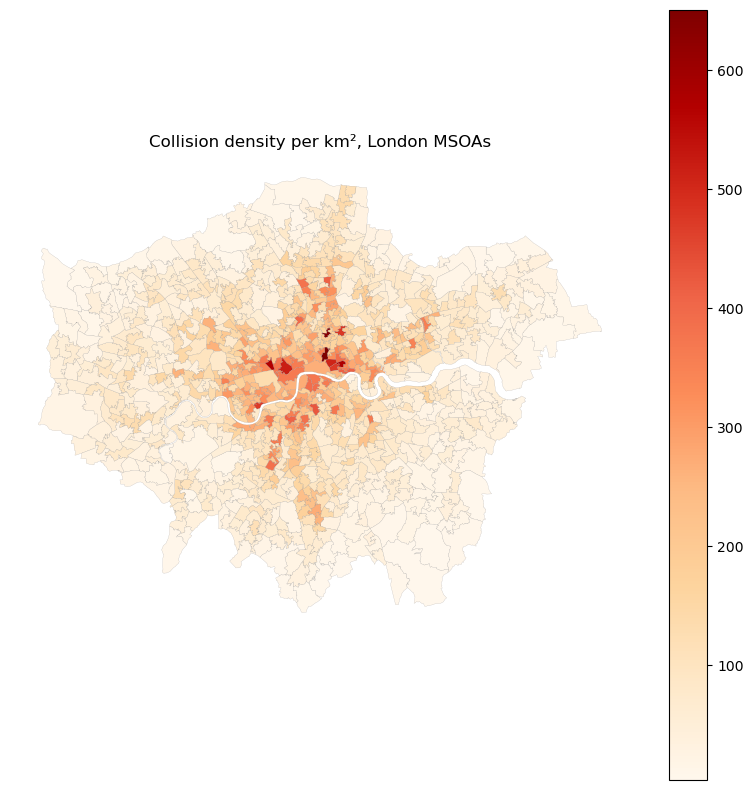

In [25]:
# Figure 5. Collision density per km², London MSOAs
fig, ax = plt.subplots(figsize=(10, 10))

analysis_gdf.plot(
    column="collision_density_per_km2",
    cmap="OrRd",
    linewidth=0.1,
    edgecolor="grey",
    legend=True,
    ax=ax
)

ax.set_title("Collision density per km², London MSOAs")
ax.axis("off")

plt.show()

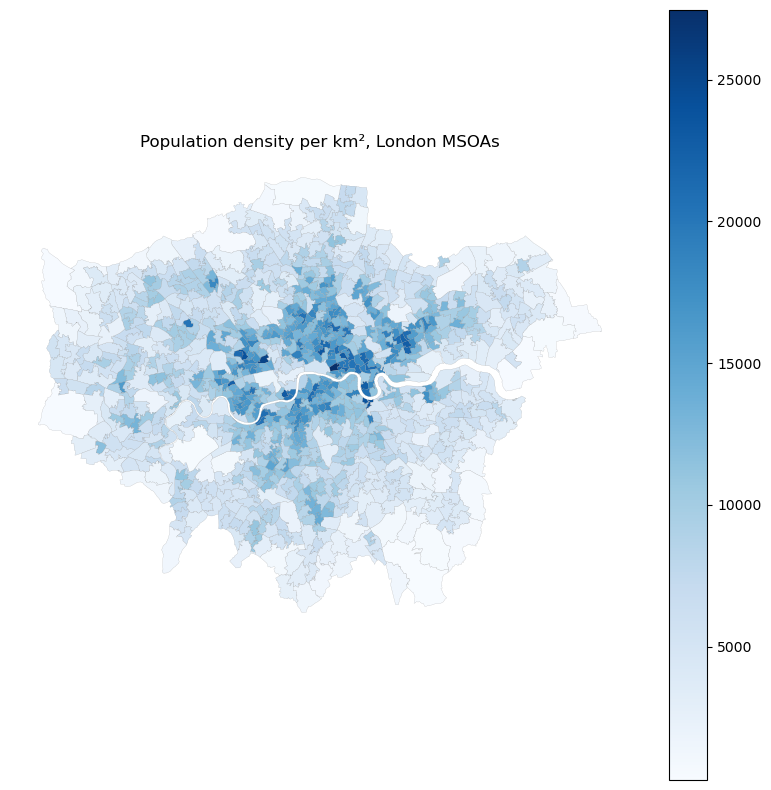

In [26]:
# Figure 6. Map Population density per km², London MSOAs
fig, ax = plt.subplots(figsize=(10, 10))

analysis_gdf.plot(
    column="pop_density_per_km2",
    cmap="Blues",
    linewidth=0.1,
    edgecolor="grey",
    legend=True,
    ax=ax
)

ax.set_title("Population density per km², London MSOAs")
ax.axis("off")

plt.show()

In [27]:
# Top 10 highest casualty-rate MSOAs
top10_rate = analysis_gdf[[
    "msoa21cd",
    "msoa21nm",
    "lad23nm",
    "annual_avg_casualty_rate_per_1000",
    "collision_density_per_km2",
    "pop_density_per_km2"
]].sort_values("annual_avg_casualty_rate_per_1000", ascending=False).head(10)

top10_rate

,msoa21cd,msoa21nm,lad23nm,annual_avg_casualty_rate_per_1000,collision_density_per_km2,pop_density_per_km2
925,E02000977,Westminster 018,Westminster,29.400882,366.929819,2796.546461
920,E02000972,Westminster 013,Westminster,17.611869,517.469413,6484.271891
926,E02000978,Westminster 019,Westminster,14.645795,132.301093,2099.548711
6850,E02007111,Hackney 033,Hackney,12.985524,650.404674,10804.460505
918,E02000970,Westminster 011,Westminster,12.505317,368.650180,6451.835540
183,E02000193,Camden 028,Camden,11.720385,361.647283,6595.231754
0,E02000001,City of London 001,City of London,11.011846,267.238271,5224.110615
915,E02000967,Westminster 008,Westminster,10.780669,221.532040,4569.363730
494,E02000524,Hillingdon 031,Hillingdon,10.693813,19.409833,493.438920
178,E02000186,Camden 021,Camden,9.309401,267.868358,6570.770840


In [28]:
# Correlation table
desc_vars = [
    "annual_avg_casualty_rate_per_1000",
    "collision_density_per_km2",
    "pop_density_per_km2",
    "avg_speed_limit",
    "prop_dark",
    "prop_wet",
    "prop_junction",
    "prop_urban"
]

desc_vars = [c for c in desc_vars if c in analysis_gdf.columns]

analysis_gdf[desc_vars].corr().round(2)

,annual_avg_casualty_rate_per_1000,collision_density_per_km2,pop_density_per_km2,avg_speed_limit,prop_dark,prop_wet,prop_junction,prop_urban
annual_avg_casualty_rate_per_1000,1.00,0.62,0.04,-0.05,0.14,-0.15,0.06,-0.05
collision_density_per_km2,0.62,1.00,0.70,-0.43,0.23,-0.28,0.41,0.21
pop_density_per_km2,0.04,0.70,1.00,-0.52,0.21,-0.29,0.47,0.29
avg_speed_limit,-0.05,-0.43,-0.52,1.00,0.01,0.22,-0.60,-0.46
prop_dark,0.14,0.23,0.21,0.01,1.00,0.05,0.03,0.08
prop_wet,-0.15,-0.28,-0.29,0.22,0.05,1.00,-0.16,-0.08
prop_junction,0.06,0.41,0.47,-0.60,0.03,-0.16,1.00,0.39
prop_urban,-0.05,0.21,0.29,-0.46,0.08,-0.08,0.39,1.00


To assess whether casualty rates are spatially clustered rather than randomly arranged, global Moran’s I is calculated using Queen contiguity weights.

In [29]:
# Import packages
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

In [30]:
w = Queen.from_dataframe(analysis_gdf, use_index=False)
w.transform = "r"

print(w.n)
print(w.mean_neighbors)

1002
5.722554890219561


In [31]:
y = analysis_gdf["annual_avg_casualty_rate_per_1000"].fillna(0).values

moran_rate = Moran(y, w)

print(f"Moran's I: {moran_rate.I:.4f}")
print(f"Expected I: {moran_rate.EI:.4f}")
print(f"p-value: {moran_rate.p_sim:.4f}")
print(f"z-score: {moran_rate.z_sim:.4f}")

Moran's I: 0.4012
Expected I: -0.0010
p-value: 0.0010
z-score: 22.2913


A positive and statistically significant Moran’s I indicates that casualty rates are spatially clustered rather than randomly distributed across London MSOAs. This supports moving beyond descriptive mapping to neighbourhood-level modelling, in order to test whether area-level characteristics help explain the observed spatial pattern, although any regression results should still be interpreted cautiously because spatial dependence may remain in the residuals.

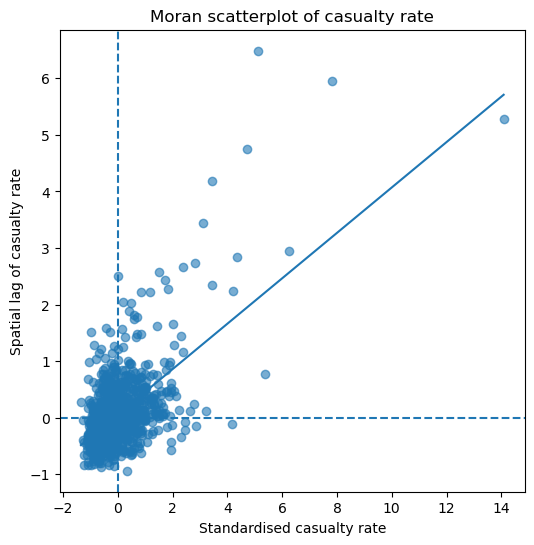

In [32]:
# Figure 7. Moran Scatterplot of Casualty Rate
# Reset index so row positions match spatial weights IDs
analysis_gdf = analysis_gdf.reset_index(drop=True).copy()

# Rebuild weights after resetting index
w = Queen.from_dataframe(analysis_gdf, use_index=False)
w.transform = "r"

# Standardised casualty rate as a NumPy array
y = analysis_gdf["annual_avg_casualty_rate_per_1000"].fillna(0).to_numpy()
z = (y - y.mean()) / y.std()

# Spatial lag using neighbour positions
lag_z = np.array([
    z[w.neighbors[i]].mean() if len(w.neighbors[i]) > 0 else np.nan
    for i in range(len(z))
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(z, lag_z, alpha=0.6)

valid = ~np.isnan(lag_z)
coef = np.polyfit(z[valid], lag_z[valid], 1)
line_x = np.linspace(z.min(), z.max(), 100)
line_y = coef[0] * line_x + coef[1]
ax.plot(line_x, line_y)

ax.axhline(0, linestyle="--")
ax.axvline(0, linestyle="--")

ax.set_title("Moran scatterplot of casualty rate")
ax.set_xlabel("Standardised casualty rate")
ax.set_ylabel("Spatial lag of casualty rate")

plt.show()

In [33]:
# LISA
lisa = Moran_Local(y, w)

analysis_gdf["lisa_i"] = lisa.Is
analysis_gdf["lisa_p"] = lisa.p_sim
analysis_gdf["lisa_q"] = lisa.q

analysis_gdf[["lisa_i", "lisa_p", "lisa_q"]].head()

analysis_gdf["lisa_cluster"] = "Not significant"

sig = analysis_gdf["lisa_p"] < 0.05

analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 1), "lisa_cluster"] = "High-High"
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 2), "lisa_cluster"] = "Low-High"
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 3), "lisa_cluster"] = "Low-Low"
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 4), "lisa_cluster"] = "High-Low"

analysis_gdf["lisa_cluster"].value_counts()

lisa_cluster
Not significant    821
Low-Low             81
High-High           60
Low-High            23
High-Low            17
Name: count, dtype: int64

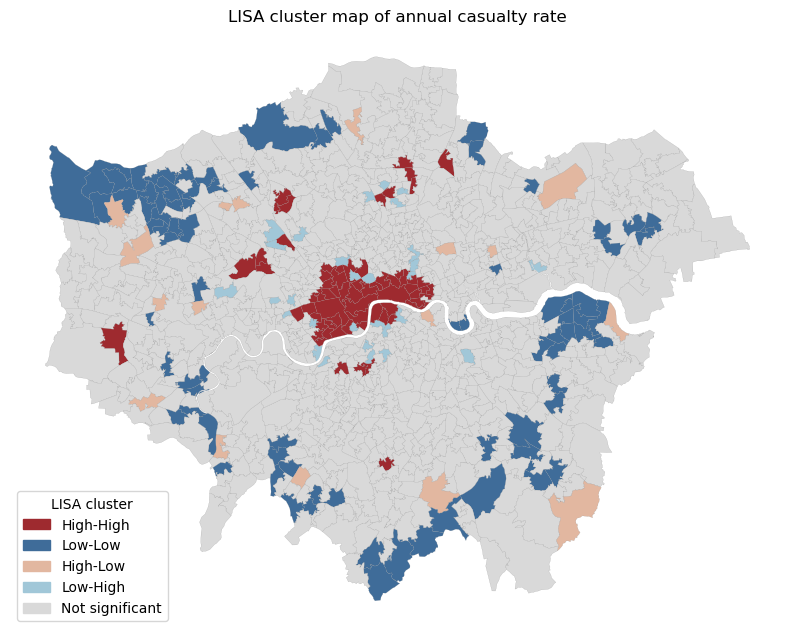

In [34]:
# Figure 8. Map LISA clusters
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from libpysal.weights import Queen
from esda.moran import Moran_Local

cluster_colors = {
    "High-High": "#9e2a2f",
    "Low-Low": "#3f6c99",
    "High-Low": "#e2b7a0",
    "Low-High": "#a1c7d8",
    "Not significant": "#d9d9d9"
}

# Reset index so row positions match spatial weights IDs
analysis_gdf = analysis_gdf.reset_index(drop=True).copy()

# Build Queen contiguity weights
w = Queen.from_dataframe(analysis_gdf, use_index=False)
w.transform = "r"

# Outcome as NumPy array
y = analysis_gdf["annual_avg_casualty_rate_per_1000"].fillna(0).to_numpy()

# Local Moran's I
lisa = Moran_Local(y, w)

analysis_gdf["lisa_i"] = lisa.Is
analysis_gdf["lisa_p"] = lisa.p_sim
analysis_gdf["lisa_q"] = lisa.q

# Create cluster labels
analysis_gdf["lisa_cluster"] = "Not significant"

sig = analysis_gdf["lisa_p"] < 0.05
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 1), "lisa_cluster"] = "High-High"
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 2), "lisa_cluster"] = "Low-High"
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 3), "lisa_cluster"] = "Low-Low"
analysis_gdf.loc[sig & (analysis_gdf["lisa_q"] == 4), "lisa_cluster"] = "High-Low"

cluster_order = ["High-High", "Low-Low", "High-Low", "Low-High", "Not significant"]

analysis_gdf["lisa_cluster"] = pd.Categorical(
    analysis_gdf["lisa_cluster"],
    categories=cluster_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(10, 10))

analysis_gdf.plot(
    color=analysis_gdf["lisa_cluster"].map(cluster_colors),
    linewidth=0.1,
    edgecolor="grey",
    ax=ax
)

legend_handles = [
    mpatches.Patch(color=cluster_colors[label], label=label)
    for label in cluster_order
]

ax.legend(
    handles=legend_handles,
    title="LISA cluster",
    loc="lower left",
    frameon=True
)

ax.set_title("LISA cluster map of annual casualty rate")
ax.axis("off")

plt.show()

This shows that casualty risk is not only uneven but also spatially structured, with clear hotspots and coldspots.

In [35]:
# Upgraded London dataset
analysis_gdf.to_file(output_dir / "msoa_analysis_london_upgraded.gpkg", driver="GPKG")

analysis_gdf.drop(columns="geometry").to_csv(
    output_dir / "msoa_analysis_london_upgraded.csv",
    index=False
)

#### Modelling preparation and nested OLS
The next stage builds an explanatory modelling dataset by combining casualty-rate outcomes with road-environment indicators, traffic-context measures, spatial-intensity measures, and deprivation.

In [36]:
vehicle_usecols = [
    "collision_index",
    "vehicle_reference"
]

vehicles_raw = pd.read_csv(
    vehicle_file,
    usecols=vehicle_usecols,
    low_memory=True
)

vehicles_raw = clean_columns(vehicles_raw)

vehicles_per_collision = (
    vehicles_raw
    .groupby("collision_index", as_index=False)
    .size()
    .rename(columns={"size": "n_vehicles"})
)

# Attach collisions from MSOA
collisions_msoa = collisions_msoa.merge(
    vehicles_per_collision,
    on="collision_index",
    how="left"
)

collisions_msoa["n_vehicles"] = collisions_msoa["n_vehicles"].fillna(0)

In [37]:
# Rebuild the MSOA summary 
collisions_msoa["speed_limit"] = pd.to_numeric(collisions_msoa["speed_limit"], errors="coerce")
collisions_msoa["light_conditions"] = pd.to_numeric(collisions_msoa["light_conditions"], errors="coerce")
collisions_msoa["road_surface_conditions"] = pd.to_numeric(collisions_msoa["road_surface_conditions"], errors="coerce")
collisions_msoa["junction_detail"] = pd.to_numeric(collisions_msoa["junction_detail"], errors="coerce")

collision_counts_msoa_strong = (
    collisions_msoa
    .groupby(["msoa21cd", "msoa21nm"], as_index=False)
    .agg(
        total_collisions=("collision_index", "size"),
        total_casualties=("number_of_casualties", "sum"),
        avg_speed_limit=("speed_limit", "mean"),
        avg_vehicles=("n_vehicles", "mean"),
        prop_dark=("light_conditions", lambda s: (s != 1).mean()),
        prop_wet=("road_surface_conditions", lambda s: s.isin([2, 3, 4]).mean()),
        prop_junction=("junction_detail", lambda s: (s != 0).mean()),
        prop_high_speed=("speed_limit", lambda s: (s >= 40).mean())
    )
)

collision_counts_msoa_strong.head()

,msoa21cd,msoa21nm,total_collisions,total_casualties,avg_speed_limit,avg_vehicles,prop_dark,prop_wet,prop_junction,prop_high_speed
0,E02000001,City of London 001,773,832,20.232859,1.659767,0.337646,0.174644,0.673997,0.000000
1,E02000002,Barking and Dagenham 001,68,90,33.823529,2.014706,0.397059,0.176471,0.632353,0.279412
2,E02000003,Barking and Dagenham 002,215,278,31.488372,1.800000,0.339535,0.241860,0.790698,0.111628
3,E02000004,Barking and Dagenham 003,24,30,30.000000,2.000000,0.333333,0.125000,0.166667,0.000000
4,E02000005,Barking and Dagenham 004,73,99,29.178082,1.945205,0.301370,0.191781,0.739726,0.013699


In [38]:
# Replace the old summary
msoa_analysis_strong = (
    msoa[["msoa21cd", "msoa21nm", "geometry"]]
    .merge(collision_counts_msoa_strong, on=["msoa21cd", "msoa21nm"], how="left")
    .merge(population_2024[["msoa21cd", "lad23cd", "lad23nm", "population"]], on="msoa21cd", how="left")
)

for col in ["total_collisions", "total_casualties"]:
    msoa_analysis_strong[col] = msoa_analysis_strong[col].fillna(0)

msoa_analysis_strong["annual_avg_casualty_rate_per_1000"] = (
    msoa_analysis_strong["total_casualties"] / 5 / msoa_analysis_strong["population"] * 1000
)

msoa_analysis_strong["five_year_casualty_rate_per_1000"] = (
    msoa_analysis_strong["total_casualties"] / msoa_analysis_strong["population"] * 1000
)

msoa_analysis_london_strong = msoa_analysis_strong[
    msoa_analysis_strong["lad23nm"].isin(london_lads)
].copy()

if msoa_analysis_london_strong.crs.to_epsg() != 27700:
    msoa_analysis_london_strong = msoa_analysis_london_strong.to_crs(27700)

msoa_analysis_london_strong["area_km2"] = msoa_analysis_london_strong.geometry.area / 1_000_000
msoa_analysis_london_strong["collision_density_per_km2"] = (
    msoa_analysis_london_strong["total_collisions"] / msoa_analysis_london_strong["area_km2"]
)
msoa_analysis_london_strong["pop_density_per_km2"] = (
    msoa_analysis_london_strong["population"] / msoa_analysis_london_strong["area_km2"]
)

print(msoa_analysis_london_strong.shape)
msoa_analysis_london_strong.head()

(1002, 19)


,msoa21cd,msoa21nm,geometry,total_collisions,total_casualties,avg_speed_limit,avg_vehicles,prop_dark,prop_wet,prop_junction,prop_high_speed,lad23cd,lad23nm,population,annual_avg_casualty_rate_per_1000,five_year_casualty_rate_per_1000,area_km2,collision_density_per_km2,pop_density_per_km2
0,E02000001,City of London 001,"POLYGON ((532135.138 182198.131, 532158.25 182...",773.0,832.0,20.232859,1.659767,0.337646,0.174644,0.673997,0.000000,E09000001,City of London,15111,11.011846,55.059228,2.892550,267.238271,5224.110615
1,E02000002,Barking and Dagenham 001,"POLYGON ((548881.563 190845.265, 548881.125 19...",68.0,90.0,33.823529,2.014706,0.397059,0.176471,0.632353,0.279412,E09000002,Barking and Dagenham,8820,2.040816,10.204082,2.166168,31.391833,4071.705443
2,E02000003,Barking and Dagenham 002,"POLYGON ((549102.438 189324.625, 548954.517 18...",215.0,278.0,31.488372,1.800000,0.339535,0.241860,0.790698,0.111628,E09000002,Barking and Dagenham,12655,4.393520,21.967602,2.143848,100.286968,5902.937609
3,E02000004,Barking and Dagenham 003,"POLYGON ((551550.056 187364.705, 551478 187263...",24.0,30.0,30.000000,2.000000,0.333333,0.125000,0.166667,0.000000,E09000002,Barking and Dagenham,7056,0.850340,4.251701,2.491467,9.632880,2832.066710
4,E02000005,Barking and Dagenham 004,"POLYGON ((549099.634 187656.076, 549161.375 18...",73.0,99.0,29.178082,1.945205,0.301370,0.191781,0.739726,0.013699,E09000002,Barking and Dagenham,11630,1.702494,8.512468,1.186372,61.532133,9802.996041


The MSOA summary was strengthened by incorporating the average number of vehicles involved per collision. This extends the explanatory framework beyond basic counts and helps capture differences in collision complexity across areas.

In [39]:
# Read IMD
imd_file = data_dir / "IMD_2025.csv"

imd_raw = pd.read_csv(imd_file, low_memory=False)
imd_raw = clean_columns(imd_raw)

imd_lsoa = imd_raw[[
    "lsoa_code__2021",
    "index_of_multiple_deprivation__imd__score",
    "total_population__mid_2022"
]].copy()

imd_lsoa = imd_lsoa.rename(columns={
    "lsoa_code__2021": "lsoa21cd",
    "index_of_multiple_deprivation__imd__score": "imd_score",
    "total_population__mid_2022": "lsoa_pop_2022"
})

imd_lsoa["lsoa21cd"] = imd_lsoa["lsoa21cd"].astype(str).str.strip()
imd_lsoa["imd_score"] = pd.to_numeric(imd_lsoa["imd_score"], errors="coerce")
imd_lsoa["lsoa_pop_2022"] = pd.to_numeric(imd_lsoa["lsoa_pop_2022"], errors="coerce")

In [40]:
# Read the LSOA lookup file
lookup_file = data_dir / "lookup.csv"

chunks = []
for chunk in pd.read_csv(
    lookup_file,
    usecols=["lsoa21cd", "msoa21cd"],
    dtype={"lsoa21cd": "string", "msoa21cd": "string"},
    encoding="latin1",
    chunksize=200000
):
    chunk = clean_columns(chunk)
    chunk["lsoa21cd"] = chunk["lsoa21cd"].str.strip()
    chunk["msoa21cd"] = chunk["msoa21cd"].str.strip()
    chunk = chunk.dropna(subset=["lsoa21cd", "msoa21cd"])
    chunk = chunk.drop_duplicates()
    chunks.append(chunk)

lookup = pd.concat(chunks, ignore_index=True).drop_duplicates()

In [41]:
# Merge 
imd_lsoa_msoa = imd_lsoa.merge(
    lookup,
    on="lsoa21cd",
    how="left"
)

print(imd_lsoa_msoa.shape)
print("Missing msoa21cd after merge:", imd_lsoa_msoa["msoa21cd"].isna().sum())

imd_msoa = (
    imd_lsoa_msoa
    .dropna(subset=["msoa21cd", "imd_score", "lsoa_pop_2022"])
    .assign(weighted_imd=lambda df: df["imd_score"] * df["lsoa_pop_2022"])
    .groupby("msoa21cd", as_index=False)
    .agg(
        imd_weighted_sum=("weighted_imd", "sum"),
        pop_sum=("lsoa_pop_2022", "sum")
    )
)

imd_msoa["imd_score"] = imd_msoa["imd_weighted_sum"] / imd_msoa["pop_sum"]
imd_msoa = imd_msoa[["msoa21cd", "imd_score"]].copy()

(33755, 4)
Missing msoa21cd after merge: 0


In [42]:
# Merge into London table
analysis_gdf = msoa_analysis_london_strong.copy()

analysis_gdf["msoa21cd"] = analysis_gdf["msoa21cd"].astype("string").str.strip()
imd_msoa["msoa21cd"] = imd_msoa["msoa21cd"].astype("string").str.strip()

analysis_gdf = analysis_gdf.merge(
    imd_msoa,
    on="msoa21cd",
    how="left"
)

print(analysis_gdf.shape)
print("Missing imd_score:", analysis_gdf["imd_score"].isna().sum())

analysis_gdf[["msoa21cd", "msoa21nm", "imd_score"]].head()

(1002, 20)
Missing imd_score: 0


,msoa21cd,msoa21nm,imd_score
0,E02000001,City of London 001,10.209772
1,E02000002,Barking and Dagenham 001,30.833167
2,E02000003,Barking and Dagenham 002,24.939802
3,E02000004,Barking and Dagenham 003,20.141616
4,E02000005,Barking and Dagenham 004,25.811686


IMD is introduced in the final model stage because deprivation may influence casualty risk indirectly through broader neighbourhood structure and transport environment, so its contribution should be assessed after accounting for more direct spatial-intensity measures.

A weighted MSOA-level deprivation measure was created by aggregating LSOA IMD scores using population weights. This allows socio-economic context to be incorporated into the area-level modelling stage.

In [43]:
# build candidate table
candidate_cols = [
    "msoa21cd",
    "msoa21nm",
    "lad23nm",
    "geometry",
    "annual_avg_casualty_rate_per_1000",
    "avg_speed_limit",
    "avg_vehicles",
    "prop_dark",
    "prop_wet",
    "prop_junction",
    "prop_high_speed",
    "collision_density_per_km2",
    "pop_density_per_km2",
    "imd_score"
]

candidate_cols = [c for c in candidate_cols if c in analysis_gdf.columns]
model_gdf = analysis_gdf[candidate_cols].copy()

model_df = model_gdf.drop(columns="geometry", errors="ignore").copy()

numeric_cols = [
    "annual_avg_casualty_rate_per_1000",
    "avg_speed_limit",
    "avg_vehicles",
    "prop_dark",
    "prop_wet",
    "prop_junction",
    "prop_high_speed",
    "collision_density_per_km2",
    "pop_density_per_km2",
    "imd_score"
]

for col in numeric_cols:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print(model_df.shape)
model_df.head()

(1002, 13)


,msoa21cd,msoa21nm,lad23nm,annual_avg_casualty_rate_per_1000,avg_speed_limit,avg_vehicles,prop_dark,prop_wet,prop_junction,prop_high_speed,collision_density_per_km2,pop_density_per_km2,imd_score
0,E02000001,City of London 001,City of London,11.011846,20.232859,1.659767,0.337646,0.174644,0.673997,0.000000,267.238271,5224.110615,10.209772
1,E02000002,Barking and Dagenham 001,Barking and Dagenham,2.040816,33.823529,2.014706,0.397059,0.176471,0.632353,0.279412,31.391833,4071.705443,30.833167
2,E02000003,Barking and Dagenham 002,Barking and Dagenham,4.393520,31.488372,1.800000,0.339535,0.241860,0.790698,0.111628,100.286968,5902.937609,24.939802
3,E02000004,Barking and Dagenham 003,Barking and Dagenham,0.850340,30.000000,2.000000,0.333333,0.125000,0.166667,0.000000,9.632880,2832.066710,20.141616
4,E02000005,Barking and Dagenham 004,Barking and Dagenham,1.702494,29.178082,1.945205,0.301370,0.191781,0.739726,0.013699,61.532133,9802.996041,25.811686


The final modelling table includes the casualty-rate outcome together with predictors representing speed environment, vehicle involvement, lighting and surface conditions, junction context, spatial intensity, and deprivation.

In [44]:
# Define the nested models
block_a = [
    "avg_speed_limit",
    "avg_vehicles",
    "prop_dark",
    "prop_wet",
    "prop_junction",
    "prop_high_speed"
]

block_b_extra = [
    "collision_density_per_km2",
    "pop_density_per_km2"
]

block_c_extra = [
    "imd_score"
]

block_a = [c for c in block_a if c in model_df.columns]
block_b_extra = [c for c in block_b_extra if c in model_df.columns]
block_c_extra = [c for c in block_c_extra if c in model_df.columns]

models = {
    "A_collision_conditions": block_a,
    "B_plus_spatial_intensity": block_a + block_b_extra,
    "C_plus_deprivation": block_a + block_b_extra + block_c_extra
}

models

{'A_collision_conditions': ['avg_speed_limit',
  'avg_vehicles',
  'prop_dark',
  'prop_wet',
  'prop_junction',
  'prop_high_speed'],
 'B_plus_spatial_intensity': ['avg_speed_limit',
  'avg_vehicles',
  'prop_dark',
  'prop_wet',
  'prop_junction',
  'prop_high_speed',
  'collision_density_per_km2',
  'pop_density_per_km2'],
 'C_plus_deprivation': ['avg_speed_limit',
  'avg_vehicles',
  'prop_dark',
  'prop_wet',
  'prop_junction',
  'prop_high_speed',
  'collision_density_per_km2',
  'pop_density_per_km2',
  'imd_score']}

In [45]:
# Correlations 
for name, predictors in models.items():
    temp = model_df[["annual_avg_casualty_rate_per_1000"] + predictors].dropna().copy()
    print(f"\n{name}")
    display(temp.corr(numeric_only=True).round(2))


A_collision_conditions


,annual_avg_casualty_rate_per_1000,avg_speed_limit,avg_vehicles,prop_dark,prop_wet,prop_junction,prop_high_speed
annual_avg_casualty_rate_per_1000,1.00,-0.05,-0.01,0.14,-0.15,0.06,0.10
avg_speed_limit,-0.05,1.00,0.32,0.01,0.22,-0.60,0.80
avg_vehicles,-0.01,0.32,1.00,0.02,-0.01,-0.15,0.38
prop_dark,0.14,0.01,0.02,1.00,0.05,0.03,0.05
prop_wet,-0.15,0.22,-0.01,0.05,1.00,-0.16,0.10
prop_junction,0.06,-0.60,-0.15,0.03,-0.16,1.00,-0.56
prop_high_speed,0.10,0.80,0.38,0.05,0.10,-0.56,1.00



B_plus_spatial_intensity


,annual_avg_casualty_rate_per_1000,avg_speed_limit,avg_vehicles,prop_dark,prop_wet,prop_junction,prop_high_speed,collision_density_per_km2,pop_density_per_km2
annual_avg_casualty_rate_per_1000,1.00,-0.05,-0.01,0.14,-0.15,0.06,0.10,0.62,0.04
avg_speed_limit,-0.05,1.00,0.32,0.01,0.22,-0.60,0.80,-0.43,-0.52
avg_vehicles,-0.01,0.32,1.00,0.02,-0.01,-0.15,0.38,-0.13,-0.19
prop_dark,0.14,0.01,0.02,1.00,0.05,0.03,0.05,0.23,0.21
prop_wet,-0.15,0.22,-0.01,0.05,1.00,-0.16,0.10,-0.28,-0.29
prop_junction,0.06,-0.60,-0.15,0.03,-0.16,1.00,-0.56,0.41,0.47
prop_high_speed,0.10,0.80,0.38,0.05,0.10,-0.56,1.00,-0.25,-0.36
collision_density_per_km2,0.62,-0.43,-0.13,0.23,-0.28,0.41,-0.25,1.00,0.70
pop_density_per_km2,0.04,-0.52,-0.19,0.21,-0.29,0.47,-0.36,0.70,1.00



C_plus_deprivation


,annual_avg_casualty_rate_per_1000,avg_speed_limit,avg_vehicles,prop_dark,prop_wet,prop_junction,prop_high_speed,collision_density_per_km2,pop_density_per_km2,imd_score
annual_avg_casualty_rate_per_1000,1.00,-0.05,-0.01,0.14,-0.15,0.06,0.10,0.62,0.04,0.16
avg_speed_limit,-0.05,1.00,0.32,0.01,0.22,-0.60,0.80,-0.43,-0.52,-0.10
avg_vehicles,-0.01,0.32,1.00,0.02,-0.01,-0.15,0.38,-0.13,-0.19,-0.09
prop_dark,0.14,0.01,0.02,1.00,0.05,0.03,0.05,0.23,0.21,0.29
prop_wet,-0.15,0.22,-0.01,0.05,1.00,-0.16,0.10,-0.28,-0.29,-0.13
prop_junction,0.06,-0.60,-0.15,0.03,-0.16,1.00,-0.56,0.41,0.47,0.11
prop_high_speed,0.10,0.80,0.38,0.05,0.10,-0.56,1.00,-0.25,-0.36,0.02
collision_density_per_km2,0.62,-0.43,-0.13,0.23,-0.28,0.41,-0.25,1.00,0.70,0.35
pop_density_per_km2,0.04,-0.52,-0.19,0.21,-0.29,0.47,-0.36,0.70,1.00,0.41
imd_score,0.16,-0.10,-0.09,0.29,-0.13,0.11,0.02,0.35,0.41,1.00


According to the output, collision density is the most important single predictor at the descriptive stage. By contrast, population density shows only a weak bivariate association with casualty rate, while average speed limit and wet-condition proportion are slightly negative. 

These weaker or negative correlations should not be interpreted too literally on their own, because they may reflect broader urban structure, network design, or correlations between predictors rather than simple one-directional effects.

Nested OLS models are estimated in stages. Model A includes collision-condition variables, Model B adds spatial-intensity variables, and Model C additionally incorporates deprivation. This allows the analysis to assess whether explanatory power improves as wider urban context is added.

In [46]:
# VIF
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

for name, predictors in models.items():
    temp = model_df[predictors].dropna().copy()
    
    X = sm.add_constant(temp)
    
    vif_df = pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    
    print(f"\n{name} VIF")
    display(vif_df.sort_values("VIF", ascending=False))


A_collision_conditions VIF


,variable,VIF
0,const,522.950356
1,avg_speed_limit,3.259739
6,prop_high_speed,3.094194
5,prop_junction,1.617313
2,avg_vehicles,1.181350
4,prop_wet,1.083562
3,prop_dark,1.010874



B_plus_spatial_intensity VIF


,variable,VIF
0,const,555.001351
1,avg_speed_limit,3.668015
6,prop_high_speed,3.218231
8,pop_density_per_km2,2.315039
7,collision_density_per_km2,2.104475
5,prop_junction,1.754540
2,avg_vehicles,1.193531
4,prop_wet,1.150868
3,prop_dark,1.110067



C_plus_deprivation VIF


,variable,VIF
0,const,561.144565
1,avg_speed_limit,3.668018
6,prop_high_speed,3.266738
8,pop_density_per_km2,2.475583
7,collision_density_per_km2,2.114612
5,prop_junction,1.754581
9,imd_score,1.322877
2,avg_vehicles,1.204596
3,prop_dark,1.158290
4,prop_wet,1.152887


Variance Inflation Factors were examined to assess multicollinearity among predictors. This is important because highly correlated variables can weaken coefficient stability and reduce interpretability in OLS models.

In [47]:
# Fit nested models
ols_results = []
ols_models = {}

for name, predictors in models.items():
    temp = model_df[["annual_avg_casualty_rate_per_1000"] + predictors].dropna().copy()
    
    y = temp["annual_avg_casualty_rate_per_1000"]
    X = sm.add_constant(temp[predictors])
    
    ols_model = sm.OLS(y, X).fit()
    
    ols_models[name] = ols_model
    
    ols_results.append({
        "model": name,
        "n": len(temp),
        "r2": ols_model.rsquared,
        "adj_r2": ols_model.rsquared_adj,
        "aic": ols_model.aic,
        "bic": ols_model.bic
    })
    
    print(f"\n{name}")
    print(ols_model.summary())


A_collision_conditions
                                    OLS Regression Results                                   
Dep. Variable:     annual_avg_casualty_rate_per_1000   R-squared:                       0.090
Model:                                           OLS   Adj. R-squared:                  0.085
Method:                                Least Squares   F-statistic:                     16.48
Date:                               Sun, 26 Apr 2026   Prob (F-statistic):           3.59e-18
Time:                                       16:29:35   Log-Likelihood:                -2009.9
No. Observations:                               1002   AIC:                             4034.
Df Residuals:                                    995   BIC:                             4068.
Df Model:                                          6                                         
Covariance Type:                           nonrobust                                         
                      coef    std er

In [48]:
# Table 2. Compare OLS models
ols_results_df = pd.DataFrame(ols_results).sort_values("r2", ascending=False)
ols_results_df

,model,n,r2,adj_r2,aic,bic
2,C_plus_deprivation,1002,0.708457,0.705812,2899.678133,2948.775666
1,B_plus_spatial_intensity,1002,0.706696,0.704333,2903.712326,2947.900105
0,A_collision_conditions,1002,0.090391,0.084906,4033.781118,4068.149391


The nested OLS models provide an interpretable baseline for understanding which groups of variables are associated with casualty-rate variation. Improvement in fit across the nested specifications would suggest that broader spatial and socio-economic context adds explanatory value beyond immediate collision conditions alone.

#### Tree-based modelling

While OLS provides an interpretable baseline, it assumes largely linear and additive relationships. Tree-based models are therefore introduced to test whether non-linear patterns improve predictive performance. Following the supervised-learning and tree-based practical workflow, a Decision Tree is estimated first as a simple non-linear baseline, followed by a tuned Random Forest as the main ensemble model.

In [49]:
from sklearn.model_selection import train_test_split

target = "annual_avg_casualty_rate_per_1000"

ml_features = [
    "avg_speed_limit",
    "avg_vehicles",
    "prop_dark",
    "prop_wet",
    "prop_junction",
    "prop_high_speed",
    "collision_density_per_km2",
    "pop_density_per_km2",
    "imd_score"
]

ml_df = model_df[[target] + ml_features].dropna().copy()

X = ml_df[ml_features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (801, 9)
Test shape: (201, 9)


In [50]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42
)

dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

dt_train_r2 = r2_score(y_train, y_train_pred_dt)
dt_test_r2 = r2_score(y_test, y_test_pred_dt)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))
dt_test_mae = mean_absolute_error(y_test, y_test_pred_dt)

print("Decision Tree Train R-squared:", round(dt_train_r2, 3))
print("Decision Tree Test R-squared:", round(dt_test_r2, 3))
print("Decision Tree Test RMSE:", round(dt_test_rmse, 3))
print("Decision Tree Test MAE:", round(dt_test_mae, 3))

Decision Tree Train R-squared: 0.808
Decision Tree Test R-squared: 0.574
Decision Tree Test RMSE: 1.162
Decision Tree Test MAE: 0.648


In [51]:
# Tuned Decision Trees
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

dt_param_grid = {
    "max_depth": [3, 5, 8],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=1
)

dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

y_train_pred_dt = best_dt.predict(X_train)
y_test_pred_dt = best_dt.predict(X_test)

dt_train_r2 = r2_score(y_train, y_train_pred_dt)
dt_test_r2 = r2_score(y_test, y_test_pred_dt)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))
dt_test_mae = mean_absolute_error(y_test, y_test_pred_dt)

print("Best Decision Tree parameters:", dt_grid.best_params_)
print("Decision Tree CV R-squared:", round(dt_grid.best_score_, 3))
print("Decision Tree Train R-squared:", round(dt_train_r2, 3))
print("Decision Tree Test R-squared:", round(dt_test_r2, 3))
print("Decision Tree Test RMSE:", round(dt_test_rmse, 3))
print("Decision Tree Test MAE:", round(dt_test_mae, 3))

Best Decision Tree parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 5}
Decision Tree CV R-squared: 0.785
Decision Tree Train R-squared: 0.859
Decision Tree Test R-squared: 0.62
Decision Tree Test RMSE: 1.097
Decision Tree Test MAE: 0.479


The Decision Tree was tuned using 5-fold cross-validation to control model complexity and reduce overfitting. Its training, cross-validation, and test performance are reported together so that predictive fit can be assessed more robustly than with a single in-sample result.

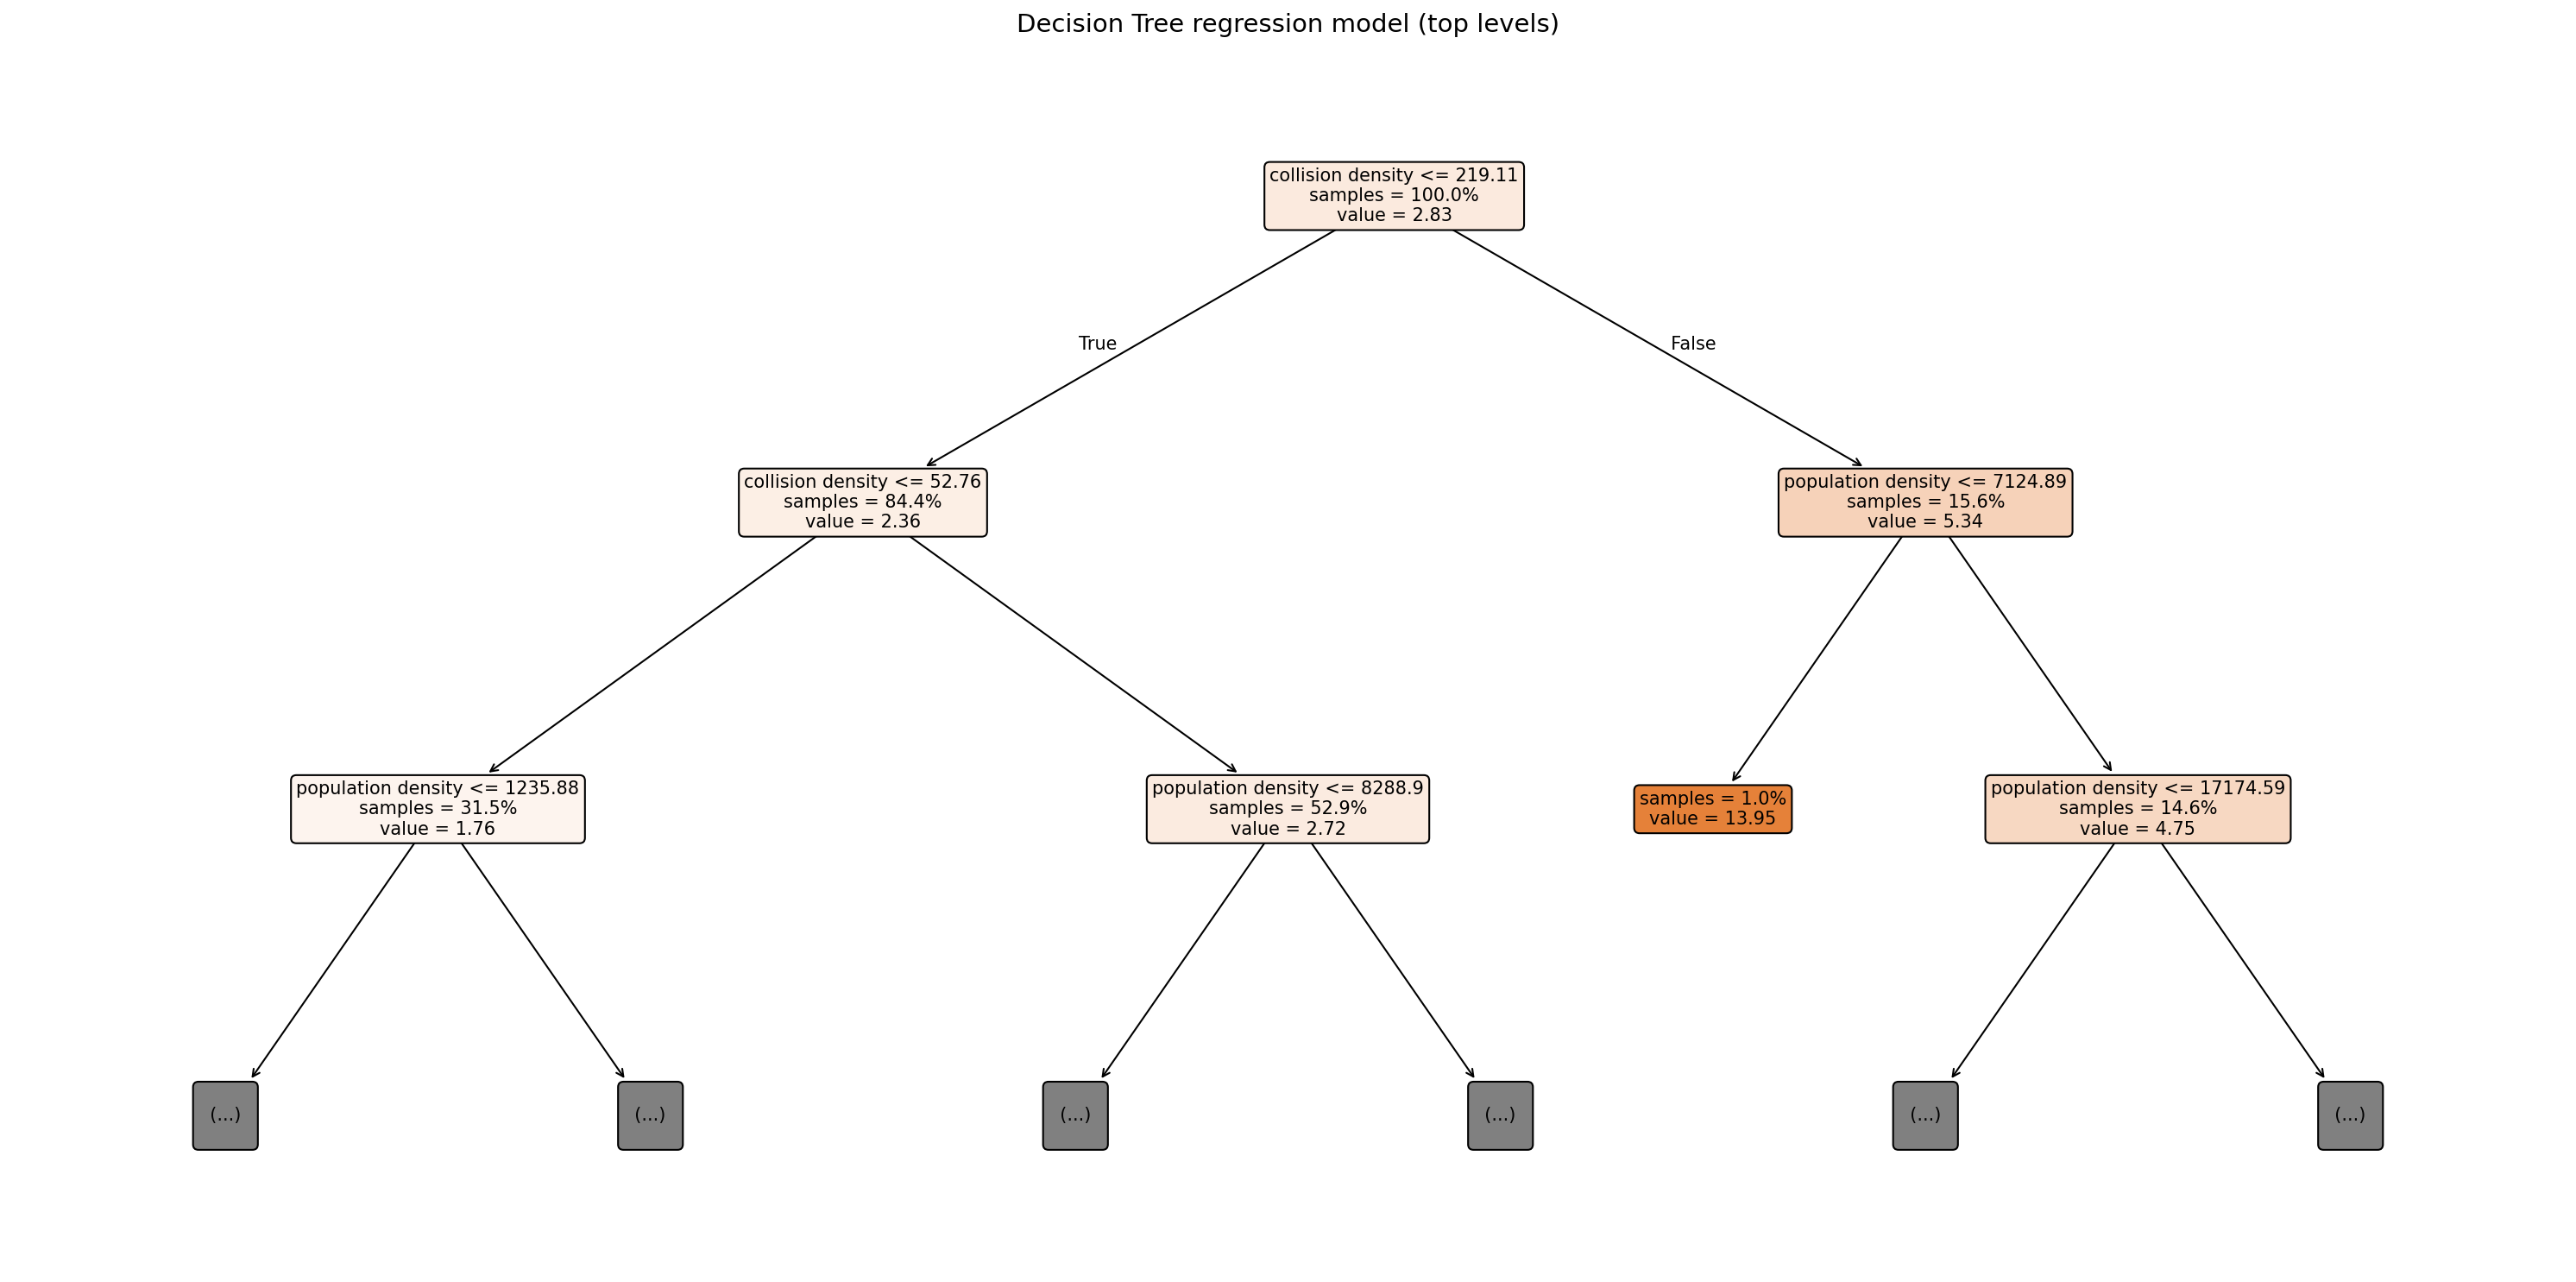

In [52]:
# Figure 9. Decision Tree regression model
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Shorter feature labels
feature_labels = {
    "collision_density_per_km2": "collision density",
    "pop_density_per_km2": "population density",
    "avg_speed_limit": "avg speed limit",
    "avg_vehicles": "avg vehicles",
    "prop_dark": "dark proportion",
    "prop_wet": "wet proportion",
    "prop_junction": "junction proportion",
    "prop_high_speed": "high-speed proportion",
    "imd_score": "IMD score"
}

plot_feature_names = [feature_labels.get(col, col) for col in X.columns]

fig, ax = plt.subplots(figsize=(20, 10), dpi=150)

plot_tree(
    best_dt,
    feature_names=plot_feature_names,
    filled=True,
    rounded=True,
    max_depth=2,          # use 2 if 3 still looks crowded
    fontsize=10,
    impurity=False,       # removes squared_error text clutter
    proportion=True,      # shows proportions instead of raw sample counts
    precision=2,
    ax=ax
)

ax.set_title("Decision Tree regression model (top levels)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

This helps illustrate how the model partitions MSOAs using threshold-based splits, although the tree is primarily used here as a non-linear baseline rather than as the final model.

In [53]:
# Tuned Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    "n_estimators": [200],
    "max_depth": [4, 8, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.8]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Random Forest CV R-squared:", round(rf_grid.best_score_, 3))
print("Random Forest Train R-squared:", round(rf_train_r2, 3))
print("Random Forest Test R-squared:", round(rf_test_r2, 3))
print("Random Forest Test RMSE:", round(rf_test_rmse, 3))
print("Random Forest Test MAE:", round(rf_test_mae, 3))

Best Random Forest parameters: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest CV R-squared: 0.816
Random Forest Train R-squared: 0.938
Random Forest Test R-squared: 0.701
Random Forest Test RMSE: 0.973
Random Forest Test MAE: 0.362


Random Forest was estimated as the main tree-based model because it can capture non-linear relationships and interactions more flexibly than OLS or a single Decision Tree. Hyperparameters were tuned using cross-validation so that the model would be evaluated on both fit and generalisation rather than default settings alone.

,Model,Train_R2,CV_R2,Test_R2,Test_RMSE,Test_MAE
0,Decision Tree,0.859,0.785,0.620,1.097,0.479
1,Random Forest,0.938,0.816,0.701,0.973,0.362


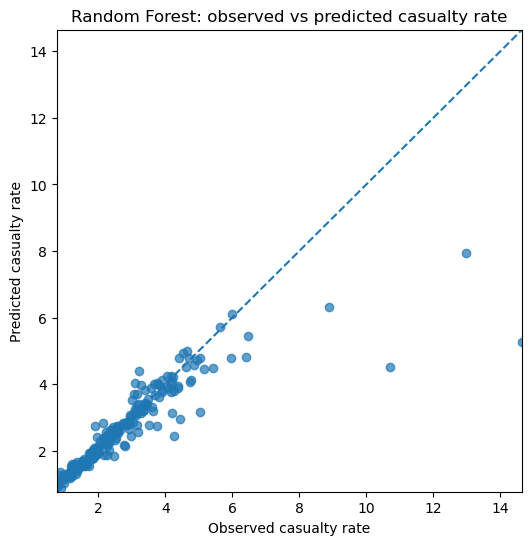

In [54]:
# Figure 10. RF: Observed vs predicted casualty rate
# Model comparison table + observed vs predicted plot
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train_R2": [dt_train_r2, rf_train_r2],
    "CV_R2": [dt_grid.best_score_, rf_grid.best_score_],
    "Test_R2": [dt_test_r2, rf_test_r2],
    "Test_RMSE": [dt_test_rmse, rf_test_rmse],
    "Test_MAE": [dt_test_mae, rf_test_mae]
})

display(results_df.round(3))

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_test_pred_rf, alpha=0.7)

lims = [
    min(y_test.min(), y_test_pred_rf.min()),
    max(y_test.max(), y_test_pred_rf.max())
]

ax.plot(lims, lims, linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Observed casualty rate")
ax.set_ylabel("Predicted casualty rate")
ax.set_title("Random Forest: observed vs predicted casualty rate")

plt.show()

Predictions align closely with observed values at low to moderate casualty rates, consistent with the model’s relatively strong test performance (R² = 0.701, RMSE = 0.973, MAE = 0.362). However, the model underpredicts several of the highest-rate MSOAs, suggesting that extreme hotspot areas remain harder to predict accurately.

In [55]:
# Permutation importance
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2",
    n_jobs=1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.round(4))

,feature,importance_mean,importance_std
6,collision_density_per_km2,2.5820,0.2483
7,pop_density_per_km2,1.5931,0.1406
5,prop_high_speed,0.0402,0.0104
4,prop_junction,0.0258,0.0056
0,avg_speed_limit,0.0172,0.0026
2,prop_dark,0.0107,0.0030
1,avg_vehicles,0.0075,0.0077
3,prop_wet,0.0035,0.0048
8,imd_score,0.0004,0.0015


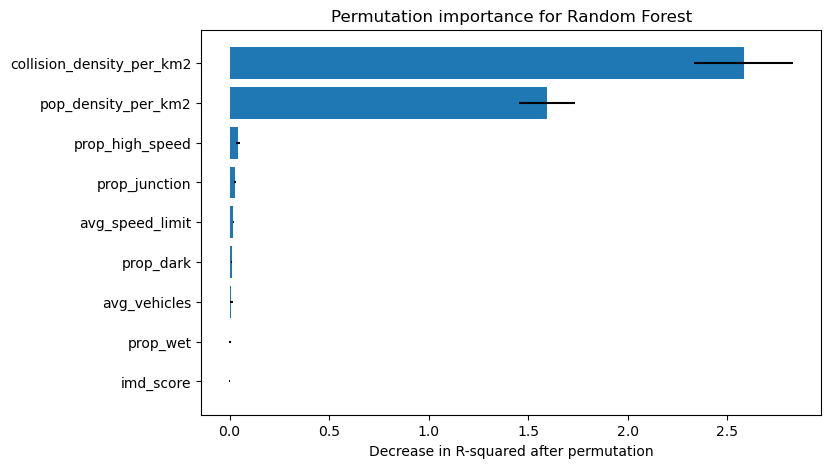

In [56]:
# Figure 11. Relative importance of the predictors in the Random Forest model

plot_df = perm_df.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)
ax.set_title("Permutation importance for Random Forest")
ax.set_xlabel("Decrease in R-squared after permutation")
plt.show()

Variables associated with larger reductions in R-squared after permutation contribute more strongly to predictive performance.

Top features used for PDP: ['collision_density_per_km2', 'pop_density_per_km2', 'prop_high_speed']


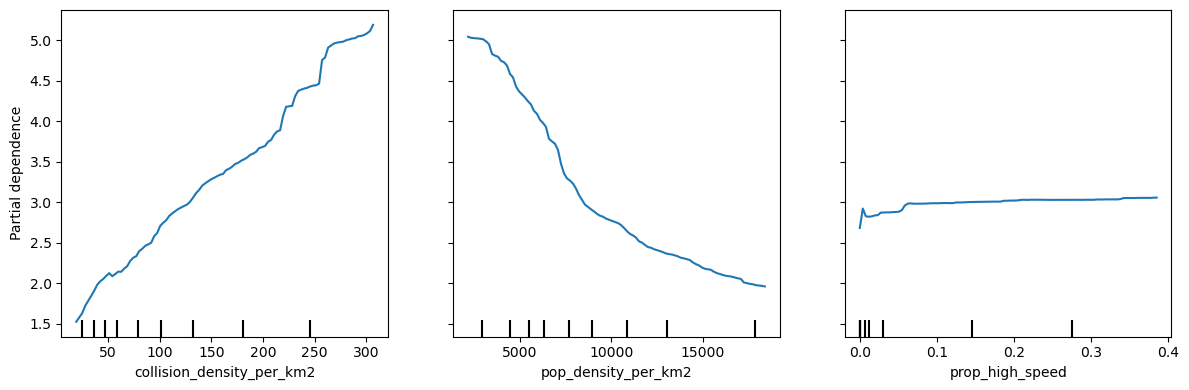

In [57]:
# Figure 12. Partial Dependence Plots
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

top_features = perm_df["feature"].head(3).tolist()
print("Top features used for PDP:", top_features)

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=top_features,
    kind="average",
    ax=ax
)
plt.tight_layout()
plt.show()

Partial dependence plots (PDPs) were used to examine how predicted casualty rates change across the range of the most important predictors. These plots help identify whether the relationships are approximately linear, strongly non-linear, or characterised by threshold effects.

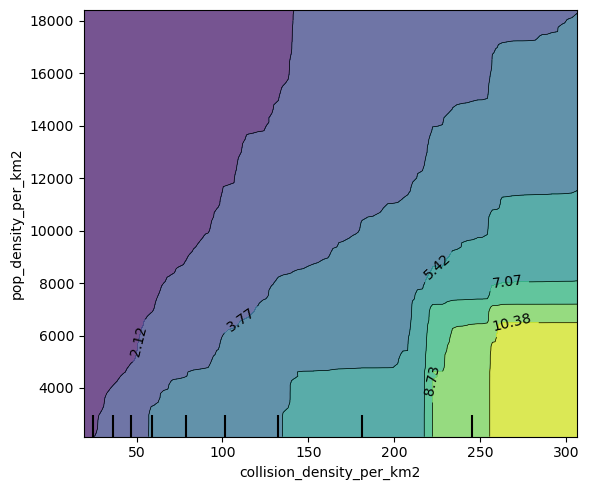

In [58]:
# Figure 13. 2D PDP interaction plot
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[(top_features[0], top_features[1])],
    kind="average",
    ax=ax
)
plt.tight_layout()
plt.show()

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

The descriptive results show clear spatial inequality in casualty risk across London MSOAs. The mean annual casualty rate is 2.84 per 1,000 residents, the median is 2.47, and the maximum is 29.40. The distribution is positively skewed, indicating that most MSOAs have relatively low rates while a smaller number experience much higher values. The map also shows that the highest rates are concentrated in inner London rather than evenly distributed across the city.

The spatial autocorrelation results reinforce this conclusion. Global Moran’s I is 0.4012 with a simulated p-value of 0.001, indicating strong and statistically significant positive spatial autocorrelation. In other words, high-rate MSOAs tend to be located near other high-rate MSOAs and vice versa. Local Moran’s I indicates that casualty risk is not randomly distributed but organised into both concentrated hotspots and concentrated coldspots. The High-High clusters are concentrated mainly in central and inner London, particularly around Westminster, Camden, and nearby areas, consistent with dense road networks, high traffic intensity, and more complex movement environments. This pattern is consistent with the logic of local spatial statistics and with earlier London crash research showing that area-wide crash outcomes are shaped by spatial dependence rather than isolated local conditions alone (Anselin, 1995; Quddus, 2008).

The OLS results show that broader spatial context matters more than immediate collision conditions alone. Model A explains little of the variation in casualty rates, with an R² of 0.090. Adding collision density and population density in Model B raises this sharply to 0.707, while adding deprivation in Model C increases fit only marginally to 0.708. In the final model, collision density per square kilometre is positively associated with casualty rate, suggesting that areas with more concentrated collisions also contain more complex and conflict-heavy road environments. High-speed collisions are also positively associated with casualty rate.

Some coefficients are negative and should be interpreted cautiously. Population density becomes negative once collision density is controlled for, which may reflect lower speeds, shorter trips, and more pedestrian-oriented infrastructure in denser areas. The average speed limit is also negative, possibly because many high-rate MSOAs are central areas with lower posted limits but high traffic complexity. The negative wet-condition coefficient may similarly reflect broader travel patterns rather than a protective effect of rain. IMD remains positive and significant, but the negligible increase in R² suggests that deprivation adds little explanatory power once spatial-intensity variables are included.

The tree-based models confirm the same overall pattern. The tuned Random Forest outperforms the Decision Tree, with a test R² of 0.701 compared with 0.620 and lower RMSE and MAE. Permutation importance shows that collision density and population density are by far the most influential predictors, while IMD adds almost no extra predictive value once the other variables are included. The partial dependence plots support this interpretation, showing that predicted casualty rates vary most strongly with collision density, population density, and the proportion of high-speed collisions. Overall, the Random Forest acts as a predictive robustness check rather than a causal model.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study shows that annual road casualty risk is distributed unevenly across London MSOAs and follows a clear spatial pattern rather than random variation. Across the different methods, the results consistently indicate that casualty risk is shaped primarily by spatial intensity, especially collision density and population density, while road-condition variables and deprivation make a more limited contribution. 

Therefore, we can suggest that road-safety policy should move beyond borough-level averages and focus more directly on neighbourhood-scale hotspot intervention, where risk is repeatedly concentrated. The study also has important limitations: it is ecological, population-standardised rather than exposure-standardised, and does not fully account for spatial dependence in regression residuals. Future research could improve on this by incorporating direct exposure measures such as traffic, pedestrian, and cycling flows, alongside road-network, land-use, and daytime population data. Spatial econometric or spatio-temporal models would also help provide a stronger account of how casualty risk is distributed and how it changes over time.

## References

[[ go back to the top ]](#Table-of-contents)

- Anselin, L. (1995) ‘Local Indicators of Spatial Association-LISA’, *Geographical Analysis*, 27(2), pp. 93-115. doi: 10.1111/j.1538-4632.1995.tb00338.x.
- Breiman, L. (2001) ‘Random Forests’, *Machine Learning*, 45, pp. 5-32. doi: 10.1023/A:1010933404324.
- Ewing, R. and Dumbaugh, E. (2009) ‘The built environment and traffic safety: A review of empirical evidence’, *Journal of Planning Literature*, 23(4), pp. 347-367. doi: 10.1177/0885412209335553.
- Graham, D., Glaister, S. and Anderson, R. (2005) ‘The effects of area deprivation on the incidence of child and adult pedestrian casualties in England’, *Accident Analysis & Prevention*, 37(1), pp. 125-135. doi: 10.1016/j.aap.2004.07.002.
- Quddus, M.A. (2008) ‘Modelling area-wide count outcomes with spatial correlation and heterogeneity: an analysis of London crash data’, *Accident Analysis & Prevention*, 40(4), pp. 1486-1497. doi: 10.1016/j.aap.2008.03.009.
- Steinbach, R., Edwards, P. and Grundy, C. (2013) ‘The road most travelled: the geographic distribution of road traffic injuries in England’, *International Journal of Health Geographics*, 12, article 30. doi: 10.1186/1476-072X-12-30.
- Obasi, I.C. and Benson, C. (2023) ‘Evaluating the effectiveness of machine learning techniques in forecasting the severity of traffic accidents’, *Heliyon*, 9(8), e18812. doi: 10.1016/j.heliyon.2023.e18812.
- World Health Organization (2023) *Road traffic injuries*. Geneva: World Health Organization. Available at: [https://www.who.int/news-room/fact-sheets/detail/road-traffic-injuries](https://www.who.int/news-room/fact-sheets/detail/road-traffic-injuries).
- Department for Transport (2025) *Road Safety Open Data*. London: Department for Transport. Available at: [https://www.gov.uk/government/statistical-data-sets/road-safety-open-data](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data).
- Office for National Statistics (2025) *Middle layer Super Output Area population estimates (supporting information)*. Newport: ONS. Available at: [https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/middlesuperoutputareamidyearpopulationestimates](https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/middlesuperoutputareamidyearpopulationestimates).
- Ministry of Housing, Communities and Local Government (2019) *English Indices of Deprivation 2019*. London: MHCLG. Available at: [https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019).
- Office for National Statistics (2024) *Postcode to OA (2021) to LSOA to MSOA to LAD (August 2024) Best Fit Lookup in the UK*. Available at: [https://geoportal.statistics.gov.uk/datasets/b8451168e985446eb8269328615dec62/about](https://geoportal.statistics.gov.uk/datasets/b8451168e985446eb8269328615dec62/about).
- Office for National Statistics (2024) *Shapefile: MSOA December 2021 boundaries (EW)*. Available at: [https://geoportal.statistics.gov.uk/datasets/middle-layer-super-output-areas-december-2021-boundaries-ew-bgc-v3-2/explore?location=52.837634%2C-2.489483%2C6](https://geoportal.statistics.gov.uk/datasets/middle-layer-super-output-areas-december-2021-boundaries-ew-bgc-v3-2/explore?location=52.837634%2C-2.489483%2C6).